# S05 : Reaction Rules as Graph Rewriting

Authors:
- [Tieu-Long Phan](https://tieulongphan.github.io/), Leipzig University - Southern Denmark University


## Aim of this talktoria
This talktorial (**S05**) introduces **Double Pushout (DPO)** graph rewriting to turn reaction rules into exact, atom-mapped transformations.

Concretely, we focus on:

1. **Rule as a span**  
   Representing a reaction rule as a span $L \xleftarrow{\,l\,} K \xrightarrow{\,r\,} R$ and interpreting $L,K,R$ chemically (deleted, preserved, added).

2. **Injective matching & symmetry**  
   Finding all injective matches $m: L \hookrightarrow G$, handling automorphisms and canonical representatives.

3. **Pushout complement (deletion)**  
   Compute $D = G \setminus m(L\setminus K)$, enforce the edge-based **dangling condition** and return the restricted map $m'$.

4. **Pushout (addition)**  
   Glue $R\setminus K$ onto $D$ along $K$ to obtain the product $H$,

5. **Atom mapping from node identity**  
   Preserve node IDs across the rewrite so `atom_map = node_id`; new nodes get fresh IDs; deleted nodes disappear.

6. **Inverse application & tooling**  
   Apply rules in reverse by swapping $L$ and $R$; demonstrate using `SynReactor` for robust, implicit-H aware DPO rewriting.


## Learning outcomes

By the end of this talktorial you can:

1. Write a reaction rule as `L`, `K`, `R` (e.g. SMARTS/graphs) and state what is deleted, preserved and added in plain chemical terms.  
2. Find matches in a molecule and list all injective embeddings you can apply the rule to. 
3. Build the **pushout complement**  and check the dangling condition.  
4. Construct the **pushout**.
5. Chain the steps into a single pipeline (match → delete → attach) and produce exact atom maps (node IDs → `atom_map`).


## Outline

- [0. Setup & Data](#0-setup--data)
- [1. Reaction rules](#1-reaction-rules)
- [2. Double Pushout Graph Rewriting](#2-double-pushout-graph-rewriting)
- [3. SynKit](#3-synkit)
- [4. Discussion](#4-discussion)
- [5. Quiz](#5-quiz)
- [6. References](#6-references)

## 0. Setup & Data

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Hashable, Iterable, List, Tuple, Optional

import networkx as nx
from networkx.algorithms import isomorphism as iso

from rdkit import Chem
from rdkit.Chem import Draw

import rdkit
from synkit.Graph import print_graph_attributes

print("RDKit:", rdkit.__version__)
print("NetworkX:", nx.__version__)

RDKit: 2025.09.3
NetworkX: 3.6.1


**Example molecules used in this notebook**

We will use a classic *pericyclic* transformation:

- **Diene**: butadiene (SMILES: `C=CC=C`)
- **Dienophile**: ethene (SMILES: `C=C`)
- Combined as a disconnected reactant mixture: `C=CC=C.C=C`

> Chemistry caveat: this is a toy model (no stereochemistry, no substituents, no endo/exo control).
The point is to demonstrate **bond reorganisation** under a rule-based graph rewriting view.


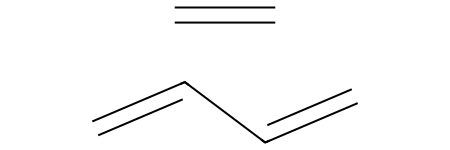

Reactant SMILES (canonical-ish): C=C.C=CC=C


In [2]:
reactant_smiles = "C=CC=C.C=C"
react = Chem.MolFromSmiles(reactant_smiles)
Chem.SanitizeMol(react)

display(react)
print("Reactant SMILES (canonical-ish):", Chem.MolToSmiles(react))

## 1. Reaction rules

A reaction rule is a **DPO span**
$$
L \xleftarrow{\;\ell\;} K \xrightarrow{\;r\;} R,
$$
where $L$ is the reacting pattern, $R$ the replacement, and $K$ the preserved
**context**.

Chemically:
$$
V_K = \text{atoms with conserved identity},
$$
$$
E_L\setminus E_K = \text{bonds broken},\qquad
E_R\setminus E_K = \text{bonds formed}.
$$
Bond-order changes appear as deletion in $L$ and creation in $R$ with endpoints fixed in $K$.

Now we will use a classic *pericyclic* transformation:

- **Diene**: butadiene (SMILES: `C=CC=C`)
- **Dienophile**: ethene (SMILES: `C=C`)
- **Product**: cyclohexen(SMILES: `C1C=CCCC1`)

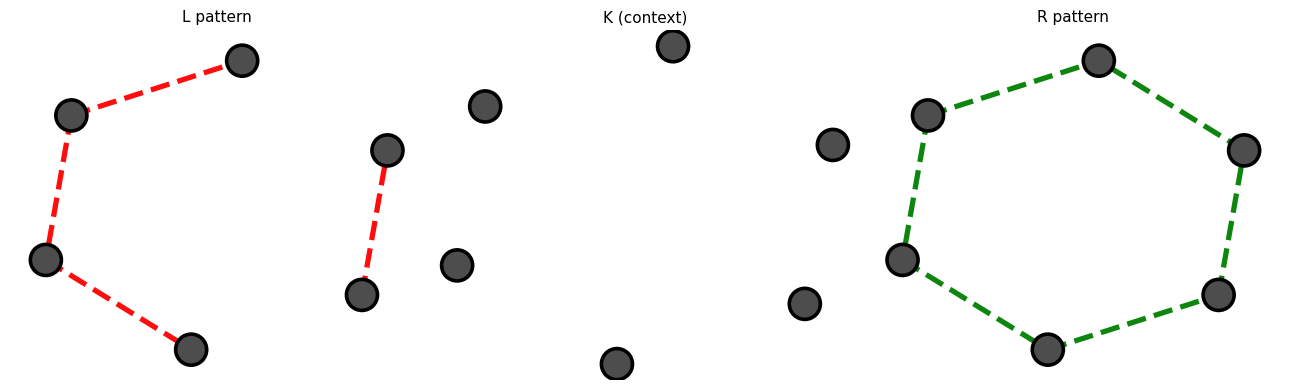

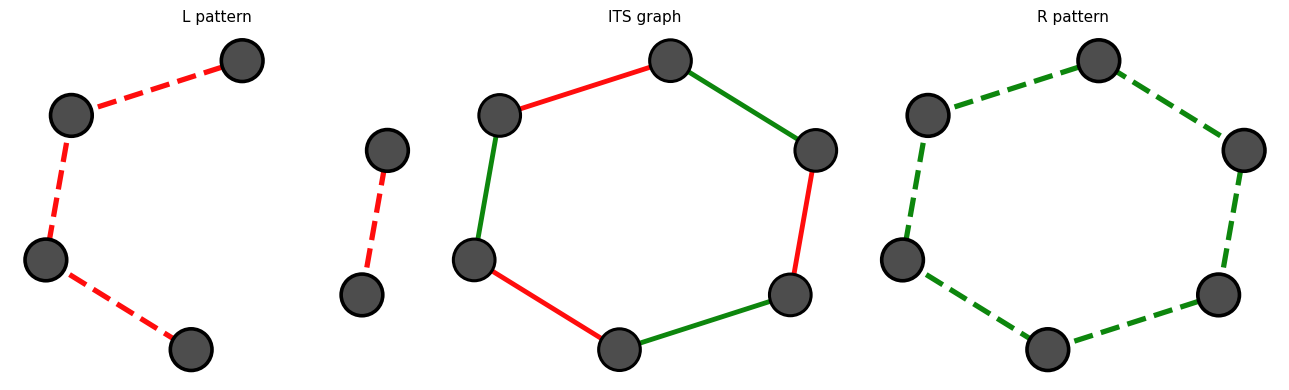

In [3]:
from synkit.IO import rsmi_to_graph
from synedu.Utils.Vis.dpo import visualize_dpo_rule

# Now we define left and right patterns with atom map
aam = '[C:5]=[C:6].[C:2]([C:3]=[C:4])=[C:1]>>[C:2]1=[C:3][C:4][C:5][C:6][C:1]1'
L, R = rsmi_to_graph(aam)

axes, dec, pos, its = visualize_dpo_rule(
    L,
    R,
    use_its=False,
    title=None,
    show_legends=False,
    show_edge_labels=False,
    show_node_labels=False,
    node_size=500,
)
axes, dec, pos, its = visualize_dpo_rule(
    L,
    R,
    use_its=True,
    title=None,
    show_legends=False,
    show_edge_labels=False,
    show_node_labels=False,
)

In [4]:
from __future__ import annotations

from typing import Tuple
import networkx as nx


def _get_k(
    L: nx.Graph,
    R: nx.Graph,
    *,
    order_key: str = "order",
    keep_k_node_attrs: Tuple[str, ...] = ("element", "aromatic", "atom_map"),
) -> nx.Graph:
    """
    Build interface graph K from L and R as:
      - nodes: intersection of node IDs
      - edges: intersection of edge endpoint pairs
      - edge order in K: min(order_L, order_R)

    This matches your desired behavior (e.g. 2.0 in L and 1.0 in R -> 1.0 in K).
    """
    K = nx.Graph()

    # nodes in both
    common_nodes = set(L.nodes()) & set(R.nodes())
    for n in common_nodes:
        # Prefer L's attrs, fallback to R; keep only stable attrs
        d = dict(L.nodes[n]) if n in L.nodes else {}
        if not d and n in R.nodes:
            d = dict(R.nodes[n])
        K.add_node(n, **{k: d[k] for k in keep_k_node_attrs if k in d})

    # edges in both (by unordered endpoints)
    common_edges = set(L.edges()) & set(R.edges())
    for u, v in common_edges:
        ol = L.edges[u, v].get(order_key, 0.0)
        orr = R.edges[u, v].get(order_key, 0.0)
        K.add_edge(u, v, **{order_key: float(min(ol, orr))})

    return K


# usage:
K = _get_k(L, R)
print_graph_attributes(K)

🔹 Nodes and their attributes:
  Node 1: {'element': 'C', 'aromatic': False, 'atom_map': 1}
  Node 2: {'element': 'C', 'aromatic': False, 'atom_map': 2}
  Node 3: {'element': 'C', 'aromatic': False, 'atom_map': 3}
  Node 4: {'element': 'C', 'aromatic': False, 'atom_map': 4}
  Node 5: {'element': 'C', 'aromatic': False, 'atom_map': 5}
  Node 6: {'element': 'C', 'aromatic': False, 'atom_map': 6}

🔸 Edges and their attributes:
  Edge 1-2: {'order': 1.0}
  Edge 2-3: {'order': 1.0}
  Edge 3-4: {'order': 1.0}
  Edge 5-6: {'order': 1.0}


## 2. Double Pushout Graph Rewriting

Two categorical pushouts compactly encode the familiar chemical workflow **delete → add** (remove broken bonds / atoms, then glue in the new fragment). The usual DPO diagram is:

$$
\begin{array}{ccccc}
\displaystyle L & \xleftarrow{\;\ell\;} & \displaystyle K & \xrightarrow{\;r\;} & \displaystyle R \\[10pt]
\displaystyle \downarrow^{m} & & \displaystyle \downarrow^{m'} & & \displaystyle \downarrow^{m''} \\[10pt]
\displaystyle G & \xleftarrow{\;g\;} & \displaystyle D & \xrightarrow{\;h\;} & \displaystyle H
\end{array}
$$

- $L$ — **left-hand side** (pattern to match: atoms/bonds that may be deleted or preserved).  
- $R$ — **right-hand side** (pattern to be inserted).  
- $K$ — **interface / context** (the part preserved during the rewrite: $K\subseteq L,R$).  
- $m$ — the **match** $L\hookrightarrow G$ (where the rule is found inside the host graph $G$).  
- $D$ — the **pushout complement** (result of deleting $L\setminus K$ from $G$).  
- $H$ — the **product graph** after the rewrite.


**Chemical intuition**

1. find the pattern $L$ in molecule $G$ (this chooses *where* the chemistry happens);  
2. remove the atoms/bonds that should disappear (everything in $L\setminus K$) — this is the **deletion** step;  
3. attach the new fragment $R\setminus K$ to the remaining context $K$ — this is the **addition** step;  
4. the result $H$ is the new molecule after the transformation.


**Formal constraints**

1. *Injective match*
The mapping $m:L\hookrightarrow G$ must be **injective** (no two distinct nodes in $L$ map to the same node of $G$). This prevents unwanted atom merging.

2. *Dangling condition (no half-bonds)*
If a node of $G$ is removed, we must not leave an edge with only one endpoint. Formally:

$$ 
   \forall\ \{x,y\}\in E(G):\qquad \big(x\in S\big)\Longrightarrow\big(y\in S\big).
   $$

   or, symmetrically,
   $$
   E(G)\cap\bigl(S\times (V(G)\setminus S)\bigr)=\varnothing.
   $$

Equivalently: every edge adjacent to a deleted node must also be deleted (i.e., both endpoints are deleted), otherwise you would create a dangling (half) bond.

3. *Chemical sanity after rewrite*
After forming $H$ check chemical invariants you care about (valence bounds, formal charge consistency, stereochemistry handling, etc.). These are *domain-specific* checks not enforced by the abstract DPO construction.



Now we try with Diels Alder reaction as an example

In [5]:
from __future__ import annotations

from typing import Optional, Tuple, Dict, Set, Iterable, List
import math

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from rdkit import Chem
from rdkit.Chem import AllChem, Draw


_ELEMENT_COLORS = {
    "C": "#4D4D4D",
    "O": "#D62728",
    "N": "#1F77B4",
    "S": "#FF7F0E",
    "Cl": "#2CA02C",
    "F": "#2CA02C",
    "Br": "#8C564B",
    "I": "#9467BD",
    "P": "#E377C2",
    "H": "#BBBBBB",
}


# ---------------------------
# small helpers
# ---------------------------
def _ensure_2d(mol: Chem.Mol) -> None:
    if mol.GetNumConformers() == 0:
        AllChem.Compute2DCoords(mol)


def _avg_edge_length(pos: Dict[int, Tuple[float, float]], G: nx.Graph) -> float:
    if G.number_of_edges() == 0:
        return 1.0
    ds: List[float] = []
    for u, v in G.edges():
        x1, y1 = pos[int(u)]
        x2, y2 = pos[int(v)]
        ds.append(math.hypot(x2 - x1, y2 - y1))
    return max(1e-6, sum(ds) / len(ds))


def _bbox(
    nodes: Iterable[int], pos: Dict[int, Tuple[float, float]]
) -> Tuple[float, float, float, float]:
    xs = [pos[int(n)][0] for n in nodes]
    ys = [pos[int(n)][1] for n in nodes]
    return min(xs), max(xs), min(ys), max(ys)


def _perp_offset(
    p1: Tuple[float, float], p2: Tuple[float, float], offset: float
) -> Tuple[float, float]:
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    L = math.hypot(dx, dy)
    if L == 0:
        return (0.0, 0.0)
    ux, uy = dx / L, dy / L
    return (-uy * offset, ux * offset)


def _index_offset_vec(
    n: int,
    G: nx.Graph,
    pos: Dict[int, Tuple[float, float]],
    *,
    base: float,
) -> Tuple[float, float]:
    # push away from neighbor centroid + tiny deterministic jitter (reduces overlaps)
    x, y = pos[n]
    nbrs = [int(m) for m in G.neighbors(n)]
    if not nbrs:
        return (0.0, base)

    cx = sum(pos[m][0] for m in nbrs) / len(nbrs)
    cy = sum(pos[m][1] for m in nbrs) / len(nbrs)

    dx = x - cx
    dy = y - cy
    L = math.hypot(dx, dy)
    if L < 1e-9:
        dx, dy, L = 0.0, 1.0, 1.0

    ux, uy = dx / L, dy / L

    ang = (n * 137.50776405003785) * (math.pi / 180.0)  # golden-angle
    jx, jy = math.cos(ang) * 0.25, math.sin(ang) * 0.25

    vx, vy = ux + jx, uy + jy
    vL = math.hypot(vx, vy)
    vx, vy = (vx / vL, vy / vL) if vL > 1e-9 else (ux, uy)
    return (vx * base, vy * base)


def _draw_bond_lines(
    ax: plt.Axes,
    p1: Tuple[float, float],
    p2: Tuple[float, float],
    *,
    order: int,
    aromatic: bool,
    aromatic_style: str,
    offset: float,
    lw: float,
) -> None:
    cap = "round"
    join = "round"

    if aromatic and aromatic_style == "dashed":
        ax.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            "--",
            color="k",
            lw=lw,
            solid_capstyle=cap,
            solid_joinstyle=join,
            zorder=2,
        )
        return

    if aromatic:
        ax.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            "-",
            color="k",
            lw=lw,
            solid_capstyle=cap,
            solid_joinstyle=join,
            zorder=2,
        )
        return

    if order <= 1:
        ax.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            "-",
            color="k",
            lw=lw,
            solid_capstyle=cap,
            solid_joinstyle=join,
            zorder=2,
        )
        return

    dx, dy = _perp_offset(p1, p2, offset)
    if order == 2:
        ax.plot(
            [p1[0] + dx, p2[0] + dx],
            [p1[1] + dy, p2[1] + dy],
            color="k",
            lw=lw,
            solid_capstyle=cap,
            solid_joinstyle=join,
            zorder=2,
        )
        ax.plot(
            [p1[0] - dx, p2[0] - dx],
            [p1[1] - dy, p2[1] - dy],
            color="k",
            lw=lw,
            solid_capstyle=cap,
            solid_joinstyle=join,
            zorder=2,
        )
    elif order == 3:
        ax.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            color="k",
            lw=lw * 0.95,
            solid_capstyle=cap,
            solid_joinstyle=join,
            zorder=2,
        )
        ax.plot(
            [p1[0] + dx, p2[0] + dx],
            [p1[1] + dy, p2[1] + dy],
            color="k",
            lw=lw * 0.95,
            solid_capstyle=cap,
            solid_joinstyle=join,
            zorder=2,
        )
        ax.plot(
            [p1[0] - dx, p2[0] - dx],
            [p1[1] - dy, p2[1] - dy],
            color="k",
            lw=lw * 0.95,
            solid_capstyle=cap,
            solid_joinstyle=join,
            zorder=2,
        )
    else:
        ax.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            "-",
            color="k",
            lw=lw,
            solid_capstyle=cap,
            solid_joinstyle=join,
            zorder=2,
        )


def _draw_aromatic_circles(
    ax: plt.Axes, G: nx.Graph, pos: Dict[int, Tuple[float, float]], scale: float
) -> None:
    for cyc in nx.cycle_basis(G):
        if len(cyc) < 5:
            continue
        if not all(bool(G.nodes[int(n)].get("aromatic", False)) for n in cyc):
            continue
        ok = True
        for i in range(len(cyc)):
            u = int(cyc[i])
            v = int(cyc[(i + 1) % len(cyc)])
            if not bool(G.edges[u, v].get("aromatic", False)):
                ok = False
                break
        if not ok:
            continue
        xs = [pos[int(n)][0] for n in cyc]
        ys = [pos[int(n)][1] for n in cyc]
        cx = sum(xs) / len(xs)
        cy = sum(ys) / len(ys)
        rs = [math.hypot(x - cx, y - cy) for x, y in zip(xs, ys)]
        r = (sum(rs) / len(rs)) * scale
        ax.add_patch(
            mpatches.Circle((cx, cy), r, fill=False, lw=1.1, color="k", zorder=1)
        )


# ---------------------------
# nicer core renderer (single axis)
# ---------------------------
def _draw_one(
    ax: plt.Axes,
    G: nx.Graph,
    pos: Dict[int, Tuple[float, float]],
    *,
    label_mode: str,
    show_indices: bool,
    indices_for_carbons: bool,
    aromatic_style: str,
    show_bond_labels: bool,
    # "chemical-ish" styling
    hide_carbon_nodes: bool,
    atom_radius_scale: float,
    bond_lw: float,
    element_fontsize: int,
    index_fontsize: int,
    # highlight
    highlight_nodes: Optional[Set[int]],
    highlight_edges: Optional[Set[Tuple[int, int]]],
    highlight_color: str,
    highlight_alpha: float,
) -> None:
    nodelist = sorted(int(n) for n in G.nodes())

    avg_len = _avg_edge_length(pos, G)
    bond_offset = avg_len * 0.09
    idx_offset = avg_len * 0.16
    atom_r = avg_len * atom_radius_scale  # circle radius in data coords

    # normalize highlight edges (undirected)
    hl_edges: Set[Tuple[int, int]] = set()
    if highlight_edges:
        for u, v in highlight_edges:
            uu, vv = int(u), int(v)
            hl_edges.add((min(uu, vv), max(uu, vv)))

    # ---- bonds first (so atoms can "mask" the line ends)
    for u, v, data in G.edges(data=True):
        u, v = int(u), int(v)
        p1, p2 = pos[u], pos[v]
        aromatic = bool(data.get("aromatic", False))
        if aromatic:
            order = 1
        else:
            try:
                order = int(round(abs(float(data.get("order", 1.0)))))
            except Exception:
                order = 1

        if hl_edges and ((min(u, v), max(u, v)) in hl_edges):
            ax.plot(
                [p1[0], p2[0]],
                [p1[1], p2[1]],
                color=highlight_color,
                lw=bond_lw * 3.0,
                alpha=highlight_alpha,
                solid_capstyle="round",
                zorder=0,
            )

        _draw_bond_lines(
            ax,
            p1,
            p2,
            order=order,
            aromatic=aromatic,
            aromatic_style=aromatic_style,
            offset=bond_offset,
            lw=bond_lw,
        )

        if show_bond_labels and (not aromatic):
            mx, my = 0.5 * (p1[0] + p2[0]), 0.5 * (p1[1] + p2[1])
            ax.text(
                mx,
                my,
                str(order),
                fontsize=8,
                ha="center",
                va="center",
                bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.9),
                zorder=8,
            )

    if aromatic_style == "circle":
        _draw_aromatic_circles(ax, G, pos, scale=0.55)

    # ---- atoms as small white circles to clean the look
    # (carbon can be hidden: still draw a tiny white mask so bonds don't run through labels)
    for n in nodelist:
        el = str(G.nodes[n].get("element", "C"))
        x, y = pos[n]
        if hide_carbon_nodes and el == "C":
            r = atom_r * 0.65
            ax.add_patch(mpatches.Circle((x, y), r, fc="white", ec="none", zorder=3))
        else:
            ax.add_patch(
                mpatches.Circle(
                    (x, y), atom_r, fc="white", ec="black", lw=1.0, zorder=3
                )
            )

    # ---- highlight nodes as colored halo
    if highlight_nodes:
        for n in highlight_nodes:
            if int(n) not in G:
                continue
            x, y = pos[int(n)]
            ax.add_patch(
                mpatches.Circle(
                    (x, y),
                    atom_r * 1.35,
                    fc="none",
                    ec=highlight_color,
                    lw=2.4,
                    alpha=highlight_alpha,
                    zorder=4,
                )
            )

    # ---- element labels (RDKit-like: hide C by default)
    for n in nodelist:
        el = str(G.nodes[n].get("element", "C"))
        if label_mode == "none":
            continue
        if label_mode == "hetero" and el == "C":
            continue
        x, y = pos[n]
        ax.text(
            x,
            y,
            el,
            ha="center",
            va="center",
            fontsize=element_fontsize,
            color=_ELEMENT_COLORS.get(el, "black") if el != "C" else "black",
            zorder=5,
        )

    # ---- indices (small, light bbox)
    if show_indices:
        for n in nodelist:
            el = str(G.nodes[n].get("element", "C"))
            if (label_mode == "hetero") and (el == "C") and (not indices_for_carbons):
                continue
            x, y = pos[n]
            dx, dy = _index_offset_vec(n, G, pos, base=idx_offset)
            ax.text(
                x + dx,
                y + dy,
                str(n),
                fontsize=index_fontsize,
                ha="center",
                va="center",
                color="black",
                bbox=dict(boxstyle="round,pad=0.08", fc="white", ec="none", alpha=0.85),
                zorder=6,
            )

    # ---- tight view
    mnx, mxx, mny, mxy = _bbox(nodelist, pos)
    pad = _avg_edge_length(pos, G) * 1.0
    ax.set_xlim(mnx - pad, mxx + pad)
    ax.set_ylim(mny - pad, mxy + pad)
    ax.set_aspect("equal")
    ax.set_axis_off()


# ---------------------------
# public API: grid per fragment (fixes your screenshot)
# ---------------------------
def draw_molecular_graph(
    G: nx.Graph,
    mol: Optional[Chem.Mol] = None,
    *,
    # layout
    separate_components: bool = True,  # <<< main fix for “fragments in corners”
    ncols: int = 3,
    figsize: Tuple[float, float] = (10, 4),
    ax: Optional[plt.Axes] = None,  # used only when separate_components=False
    # labels / bonds
    label_mode: str = "hetero",  # "all" | "hetero" | "none"
    show_indices: bool = True,
    indices_for_carbons: bool = True,
    show_bond_labels: bool = False,
    aromatic_style: str = "circle",  # "circle" | "dashed"
    # style (more “chemical” than network-graph)
    hide_carbon_nodes: bool = False,  # set True to mimic RDKit carbon omission
    atom_radius_scale: float = 0.13,
    bond_lw: float = 2.0,
    element_fontsize: int = 10,
    index_fontsize: int = 9,
    # highlighting
    highlight_nodes: Optional[Set[int]] = None,
    highlight_edges: Optional[Set[Tuple[int, int]]] = None,
    highlight_color: str = "#FFB000",
    highlight_alpha: float = 0.85,
) -> plt.Axes | Tuple[plt.Figure, List[plt.Axes]]:
    """
    Better default for disconnected reaction graphs: render EACH connected component
    in its own small panel (grid), instead of letting fragments fly to corners.

    Tip when saving: fig.savefig(..., bbox_inches="tight", pad_inches=0.02)
    """
    label_mode = label_mode.lower()
    aromatic_style = aromatic_style.lower()

    if label_mode not in {"all", "hetero", "none"}:
        raise ValueError("label_mode must be 'all', 'hetero', or 'none'")
    if aromatic_style not in {"circle", "dashed"}:
        raise ValueError("aromatic_style must be 'circle' or 'dashed'")

    # positions: RDKit 2D if available, else spring
    nodelist = sorted(int(n) for n in G.nodes())
    pos: Dict[int, Tuple[float, float]] = {}
    if mol is not None:
        _ensure_2d(mol)
        conf = mol.GetConformer(0)
        for n in nodelist:
            p = conf.GetAtomPosition(int(n))
            pos[int(n)] = (float(p.x), float(p.y))
    else:
        pos = {
            int(k): (float(v[0]), float(v[1]))
            for k, v in nx.spring_layout(G, seed=42).items()
        }

    if not separate_components:
        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)
        _draw_one(
            ax,
            G,
            pos,
            label_mode=label_mode,
            show_indices=show_indices,
            indices_for_carbons=indices_for_carbons,
            aromatic_style=aromatic_style,
            show_bond_labels=show_bond_labels,
            hide_carbon_nodes=hide_carbon_nodes,
            atom_radius_scale=atom_radius_scale,
            bond_lw=bond_lw,
            element_fontsize=element_fontsize,
            index_fontsize=index_fontsize,
            highlight_nodes=highlight_nodes,
            highlight_edges=highlight_edges,
            highlight_color=highlight_color,
            highlight_alpha=highlight_alpha,
        )
        return ax

    # ---- component grid
    comps = [sorted(map(int, c)) for c in nx.connected_components(G)]
    comps.sort(key=len, reverse=True)

    n = len(comps)
    ncols = max(1, int(ncols))
    nrows = int(math.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes_flat = [axes[r][c] for r in range(nrows) for c in range(ncols)]

    for k, ax_k in enumerate(axes_flat):
        ax_k.set_axis_off()
        if k >= n:
            continue

        nodes = comps[k]
        H = G.subgraph(nodes).copy()
        pos_k = {i: pos[i] for i in nodes}

        # restrict highlighting to this component
        hn = {i for i in (highlight_nodes or set()) if i in H}
        he = {(u, v) for (u, v) in (highlight_edges or set()) if (u in H and v in H)}

        _draw_one(
            ax_k,
            H,
            pos_k,
            label_mode=label_mode,
            show_indices=show_indices,
            indices_for_carbons=indices_for_carbons,
            aromatic_style=aromatic_style,
            show_bond_labels=show_bond_labels,
            hide_carbon_nodes=hide_carbon_nodes,
            atom_radius_scale=atom_radius_scale,
            bond_lw=bond_lw,
            element_fontsize=element_fontsize,
            index_fontsize=index_fontsize,
            highlight_nodes=hn if hn else None,
            highlight_edges=he if he else None,
            highlight_color=highlight_color,
            highlight_alpha=highlight_alpha,
        )

    fig.tight_layout()
    return fig, axes_flat[:n]

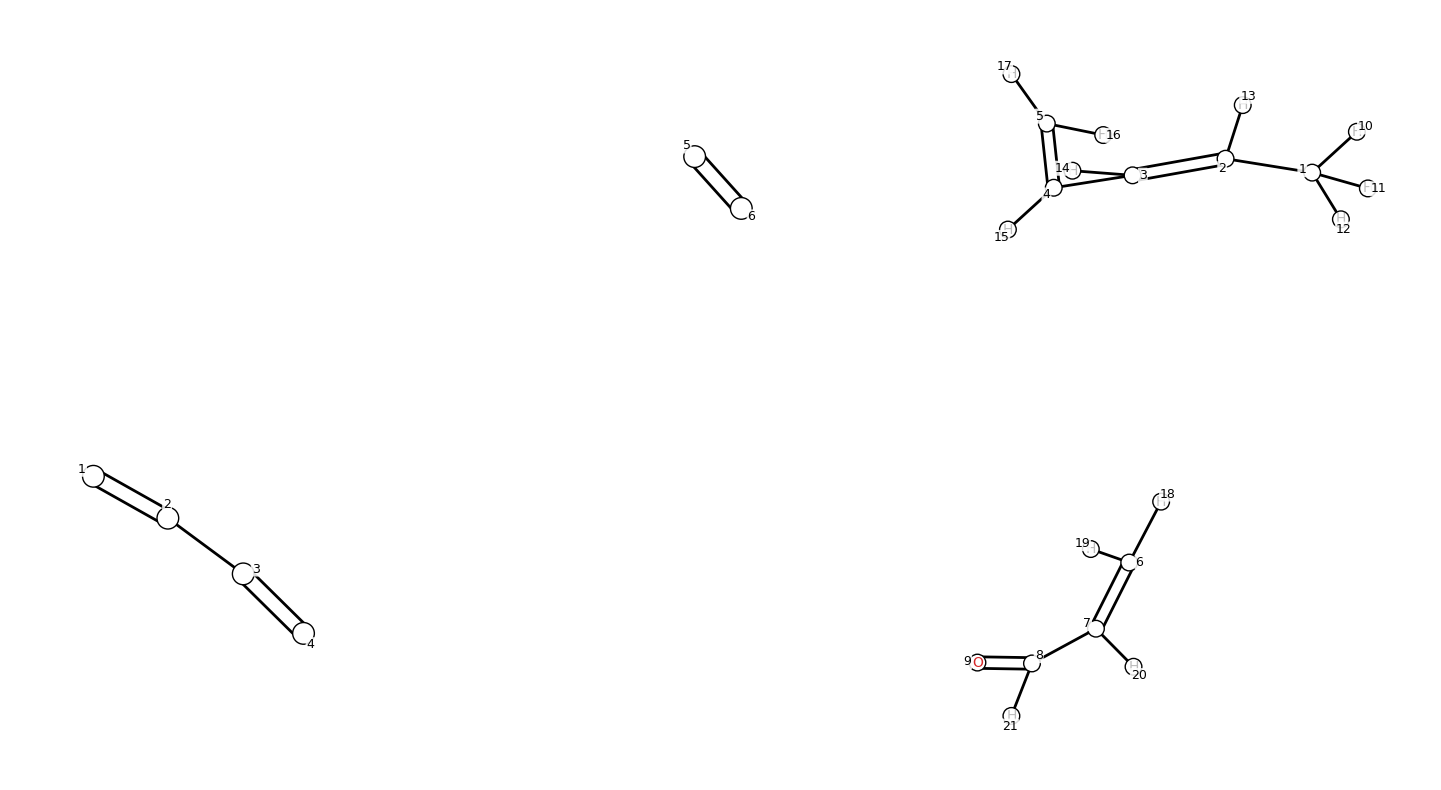

In [6]:
from synkit.IO import smiles_to_graph
from synkit.Graph.Hyrogen._misc import h_to_explicit

# for simple modeling, we expand all hydrogen nodes
input = 'CC=CC=C.C=CC=O'
G = h_to_explicit(smiles_to_graph(input))

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

draw_molecular_graph(
    L,
    show_indices=True,
    separate_components=False,  # <<< REQUIRED
    ax=ax[0],
)

draw_molecular_graph(
    G,
    show_indices=True,
    separate_components=False,  # <<< REQUIRED
    ax=ax[1],
)

plt.tight_layout()

### 2.1. Pattern matching (where a rule applies)

A reaction rule is given as a span
$$
p := \bigl( L \xleftarrow{\;\ell\;} K \xrightarrow{\;r\;} R \bigr),
$$
where $L$ is the reactant pattern, $R$ the product pattern, and $K$ the
interface of conserved atoms.

Given a host (reactant) molecular graph $G$, the rule applies at any
**injective match**
$$
m : L \hookrightarrow G,
$$
that is, a labeled subgraph monomorphism embedding the reaction pattern $L$
into the host graph $G$ and thereby identifying the reaction center.


In [7]:
from typing import Any, Callable, Dict, List

import networkx as nx
from networkx.algorithms import isomorphism as iso


def node_match(L_node: dict, G_node: dict) -> bool:
    eL = L_node.get("element")
    eG = G_node.get("element")
    return (eL is None) or (eG is None) or (eL == eG)


def edge_match(L_edge: dict, G_edge: dict) -> bool:
    oL = L_edge.get("order")
    oG = G_edge.get("order")
    return (oL is None) or (oG is None) or (float(oL) == float(oG))


def _automorphisms(
    H: nx.Graph,
    *,
    node_match: Callable[[dict, dict], bool],
    edge_match: Callable[[dict, dict], bool],
) -> List[Dict[Any, Any]]:
    GM = iso.GraphMatcher(H, H, node_match=node_match, edge_match=edge_match)
    return list(GM.isomorphisms_iter())  # H -> H

**Q1 — Pattern match**

Implement `find_pattern_match(G, L)` using `node_match`, `edge_match`, `_automorphisms`; enumerate all injective embeddings $m: L \hookrightarrow G$ and yield one canonical representative per `Aut(L)` orbit, then run on the given `L`/`G`.

---

<details> <summary><b>Solution:</b></summary>

```python
def find_pattern_match(G: nx.Graph, L: nx.Graph) -> Iterable[Dict[Any, Any]]:
    """Yield one representative per Aut(L)-orbit of subgraph monomorphisms L -> G."""
    # automorphisms of L (L -> L)
    auts = list(iso.GraphMatcher(L, L, node_match=node_match, edge_match=edge_match).isomorphisms_iter())
    L_nodes = tuple(sorted(L.nodes()))
    seen: Set[Tuple[Any, ...]] = set()

    # find embeddings (G -> L -> invert to L -> G)
    GM = iso.GraphMatcher(G, L, node_match=lambda Gd, Ld: node_match(Ld, Gd),
                                  edge_match=lambda Gd, Ld: edge_match(Ld, Gd))
    for m_G_to_L in GM.subgraph_isomorphisms_iter():
        m = {l: g for g, l in m_G_to_L.items()}  # L -> G
        key = min((tuple(m[a[n]] for n in L_nodes) for a in auts), default=tuple(m[n] for n in L_nodes))
        if key in seen:
            continue
        seen.add(key)
        yield m

maps  = find_pattern_match(G, L)
for i in maps:
    print(i)
```
Output
```text
{5: 6, 6: 7, 2: 3, 3: 4, 4: 5, 1: 2}
```

- `raw` lists all injective embeddings (here: **4** raw maps).  
- **Do not** quotient by the full `Aut(L)` when `L` is disconnected — that mixes symmetries across fragments and over-collapses distinct placements.  
- **Fix (generic):** choose **one anchor component** (e.g. largest or explicit `anchor_nodes`) and **do not** quotient that component; quotient only the other components by their own `Aut`.  
- Use a component-aware matcher (e.g. `find_pattern_match_components(anchor="largest")`).  
- With this policy your example yields **2** canonical maps (diene orientations kept distinct, ethene deduped) instead of 1.

</details>

In [8]:
import itertools
import networkx as nx
from networkx.algorithms import isomorphism as iso


def find_pattern_match_components(
    host: nx.Graph,
    pattern: nx.Graph,
    *,
    anchor: str = "largest",
):
    """
    Split the pattern into connected components; keep raw matches for the
    anchor component (so its placements stay distinct), but quotient other
    components by Aut(component).

    Returns
    -------
    list[dict]
        Each dict is a node mapping {pattern_node -> host_node}.
    """
    # --- split pattern into connected components ---
    comps = [pattern.subgraph(ns).copy() for ns in nx.connected_components(pattern)]

    if anchor == "largest":
        anchor_idx = max(
            range(len(comps)),
            key=lambda i: (comps[i].number_of_nodes(), comps[i].number_of_edges()),
        )
    else:
        anchor_idx = 0

    comp_reps = []

    # --- compute representatives per component ---
    for i, C in enumerate(comps):
        matcher = iso.GraphMatcher(
            host,
            C,
            node_match=lambda Hd, Cd: node_match(Cd, Hd),
            edge_match=lambda Hd, Cd: edge_match(Cd, Hd),
        )

        # raw matches: pattern_node -> host_node
        raw = [
            {c: h for h, c in m.items()} for m in matcher.subgraph_isomorphisms_iter()
        ]

        if i == anchor_idx:
            reps = raw
        else:
            auts = _automorphisms(C, node_match=node_match, edge_match=edge_match)
            C_nodes = tuple(sorted(C.nodes()))

            seen_keys = set()
            reps = []

            for m in raw:
                # canonical key under automorphism action
                key = min(
                    (tuple(m[a[v]] for v in C_nodes) for a in auts),
                    default=tuple(m[v] for v in C_nodes),
                )

                if key in seen_keys:
                    continue

                seen_keys.add(key)
                reps.append(m)

        comp_reps.append(reps)

    # --- combine component matches ---
    results = []

    for choice in itertools.product(*comp_reps):
        used = set()
        out = {}
        ok = True

        for m in choice:
            vals = set(m.values())
            if used & vals:
                ok = False
                break
            used |= vals
            out.update(m)

        if ok:
            results.append(out)

    return results

In [9]:
matches = find_pattern_match_components(G, L)
matches

[{5: 6, 6: 7, 2: 3, 3: 4, 4: 5, 1: 2}, {5: 6, 6: 7, 2: 4, 3: 3, 4: 2, 1: 5}]

### 2.2. Pushout Complement

Given graphs $L$, $K \subseteq L$, a host graph $G$, and an injective match
$$
m : L \hookrightarrow G,
$$
the **pushout complement** is
$$
D = G \setminus m(L \setminus K),
$$
if it exists.

**Deletion**
$$
V_{\text{del}} = m\!\left(V(L)\setminus V(K)\right), \qquad
E_{\text{del}} = \{\, e=\{u,v\}\in E(G)\mid u\in V_{\text{del}} \ \text{or}\ v\in V_{\text{del}} \,\}.
$$
$$
D = \bigl(V(G)\setminus V_{\text{del}},\; E(G)\setminus E_{\text{del}}\bigr),
$$
with all attributes and node IDs inherited from \(G\).

**Dangling condition**
$$
\forall\, \{u,v\}\in E(G):\quad
u\in V_{\text{del}} \Rightarrow v\in V_{\text{del}}.
$$

**Interface map**
$$
m' : K \hookrightarrow D, \qquad m'(v)=m(v)\ \ \forall v\in V(K).
$$



### Example — Dangling condition

Consider a **molecular graph** (ethanol):

$$
G:\quad \mathrm{C_1{-}C_2{-}O_3}
$$

Edges:
$$
E(G)=\{\{C_1,C_2\},\{C_2,O_3\}\}
$$

---

### Invalid pushout complement (dangling)

Let
$$
L = \{C_2\}, \qquad K=\varnothing,
$$
with injective match
$$
m(C_2)=C_2.
$$

Then
$$
V_{\text{del}}=\{C_2\}.
$$

But in $G$:
$$
\{C_2,O_3\}\in E(G),\quad
C_2\in V_{\text{del}},\; O_3\notin V_{\text{del}}.
$$

This would leave a **dangling bond** at $O_3$.

❌ **Dangling condition violated → no pushout complement.**

---

### Valid pushout complement (corrected)

Consider the ethanol host graph
$$
G:\quad \mathrm{C_1{-}C_2{-}O_3}.
$$

Let the rule delete the **entire molecule**:
$$
L=\{C_1,C_2,O_3\}, \qquad K=\varnothing,
$$
with injective match
$$
m(C_1)=C_1,\; m(C_2)=C_2,\; m(O_3)=O_3.
$$

Then
$$
V_{\text{del}}=\{C_1,C_2,O_3\}.
$$

Every edge of \(G\) is incident to deleted nodes and is contained in \(m(E(L))\),
so no half-edges are created.

Remaining graph:
$$
D=\varnothing.
$$

✅ **Dangling condition satisfied.**



**Q2 — Dangling condition**

Implement `violates_dangling(G, L, K, m)` to verify whether a given match `m : L -> G`
violates the DPO dangling condition (i.e. some edge in `G` is incident to a deleted node
but is not deleted as part of `L \ K`).

---

<details> <summary><b>Solution</b></summary>

```python
import networkx as nx
from typing import Dict, Hashable, Set, FrozenSet

def violates_dangling(
    G: nx.Graph,
    L: nx.Graph,
    K: nx.Graph,
    m: Dict[Hashable, Hashable],  # L.node -> G.node
) -> bool:
    
    # basic sanity checks
    if not set(K.nodes).issubset(set(L.nodes)):
        raise ValueError("K must be a subgraph of L (K.nodes ⊆ L.nodes).")
    if set(m.keys()) != set(L.nodes) and not set(L.nodes).issubset(set(m.keys())):
        # allow m to be defined on a superset but require mapping for all L.nodes
        raise ValueError("Mapping m must provide an image for every node in L.")
    if len(set(m[v] for v in L.nodes)) != len(list(L.nodes)):
        raise ValueError("Mapping m must be injective on L.nodes.")

    # nodes to be deleted: image of L \ K
    V_del: Set[Hashable] = {m[v] for v in L.nodes if v not in K.nodes}

    # edges to be deleted: image of edges in L that are not fully contained in K
    E_del: Set[FrozenSet[Hashable]] = set()
    for u, v in L.edges:
        # if at least one endpoint lies in L\K, that L-edge will be removed
        if (u not in K.nodes) or (v not in K.nodes):
            E_del.add(frozenset({m[u], m[v]}))

    # check every edge in G: if it touches a deleted node it must be in E_del
    for u, v in G.edges:
        e = frozenset({u, v})
        if (u in V_del) or (v in V_del):
            if e not in E_del:
                return True
    return False


# 1) Invalid: delete only middle carbon -> dangling at O3
L1 = nx.Graph()
L1.add_node("c2")
K1 = nx.Graph()  # empty
m1 = {"c2": 2}
print("case1 (delete c2 only) ->", violates_dangling(G, L1, K1, m1))  # True

# 2) Invalid: delete c2 + o3 but L does NOT include edge {c1,c2} -> dangling at C1
L2 = nx.Graph()
L2.add_nodes_from(["c2", "o3"])
L2.add_edge("c2", "o3")
K2 = nx.Graph()  # empty
m2 = {"c2": 2, "o3": 3}
print("case2 (delete c2+o3 but L misses c1-c2) ->", violates_dangling(G, L2, K2, m2))  # True

# 3) Valid substitution: delete O3 (leaving group), preserve C1-C2 backbone
L3 = nx.Graph()
L3.add_nodes_from(["c1", "c2", "o3"])
L3.add_edges_from([("c1", "c2"), ("c2", "o3")])
K3 = nx.Graph()
K3.add_nodes_from(["c1", "c2"])
K3.add_edge("c1", "c2")
m3 = {"c1": 1, "c2": 2, "o3": 3}
print("case3 (substitution C-C-O -> C-C-? ) ->", violates_dangling(G, L3, K3, m3))  # False
```

</details>

In [10]:
from __future__ import annotations

from typing import Any, Dict, Iterable, List, Tuple
import networkx as nx


def pushout_complement(
    L: nx.Graph,
    K: nx.Graph,
    G: nx.Graph,
    m: Dict[Any, Any],
    *,
    order_key: str = "order",
    check_injective: bool = True,
    check_structure: bool = True,
    check_dangling_nodes: bool = True,
) -> Tuple[nx.Graph, Dict[Any, Any]]:
    # --- sanity: match covers L nodes ---
    missing = [u for u in L.nodes() if u not in m]
    if missing:
        raise KeyError(f"Match m missing images for L nodes: {missing}")

    if check_injective:
        imgs = list(m.values())
        if len(set(imgs)) != len(imgs):
            raise ValueError("Match m must be injective.")

    # --- node deletions ---
    del_L_nodes = set(L.nodes()) - set(K.nodes())
    del_G_nodes = {m[u] for u in del_L_nodes}

    # dangling condition for NODE deletions (half-bonds)
    if check_dangling_nodes:
        for gx in del_G_nodes:
            for gy in G.neighbors(gx):
                if gy not in del_G_nodes:
                    raise ValueError(
                        f"Dangling condition violated: deleting node {gx} leaves edge to preserved node {gy}."
                    )

    # --- edge sets (by unordered endpoints) ---
    K_edges = {frozenset((u, v)) for u, v in K.edges()}
    L_edges = {frozenset((u, v)) for u, v in L.edges()}

    # edges to delete: those in L but not in K
    del_L_edges = [e for e in L_edges if e not in K_edges]

    # --- start D as a copy of G ---
    D = G.copy()

    # 1) delete edges in m(E(L\\K)) whose endpoints survive
    del_G_edges: List[Tuple[Any, Any]] = []
    for e in del_L_edges:
        u, v = tuple(e)
        gu, gv = m[u], m[v]
        if gu in del_G_nodes or gv in del_G_nodes:
            continue  # will be removed with node deletion
        if check_structure and not G.has_edge(gu, gv):
            raise ValueError(
                f"Match not structure-preserving: G missing edge ({gu},{gv}) for L edge ({u},{v})."
            )
        del_G_edges.append((gu, gv))
    D.remove_edges_from([(u, v) for (u, v) in del_G_edges if D.has_edge(u, v)])

    # 2) delete nodes (removes incident edges)
    D.remove_nodes_from([n for n in del_G_nodes if n in D])

    # 3) RELABEL interface edges to K's order (your key requirement)
    for u, v, kdata in K.edges(data=True):
        gu, gv = m[u], m[v]
        if gu in del_G_nodes or gv in del_G_nodes:
            # should not happen since K nodes are preserved
            raise ValueError(f"K edge ({u},{v}) maps to deleted node in G.")
        if check_structure and not D.has_edge(gu, gv):
            raise ValueError(
                f"Interface edge ({gu},{gv}) missing in D after deletions."
            )
        if order_key not in kdata:
            raise KeyError(f"K edge ({u},{v}) missing '{order_key}'")
        # overwrite order in D to the interface (base) order
        D.edges[gu, gv][order_key] = float(kdata[order_key])

    m_K = {k: m[k] for k in K.nodes()}
    return D, m_K

Now we have 2 `D` since we have 2 maps

<Axes: >

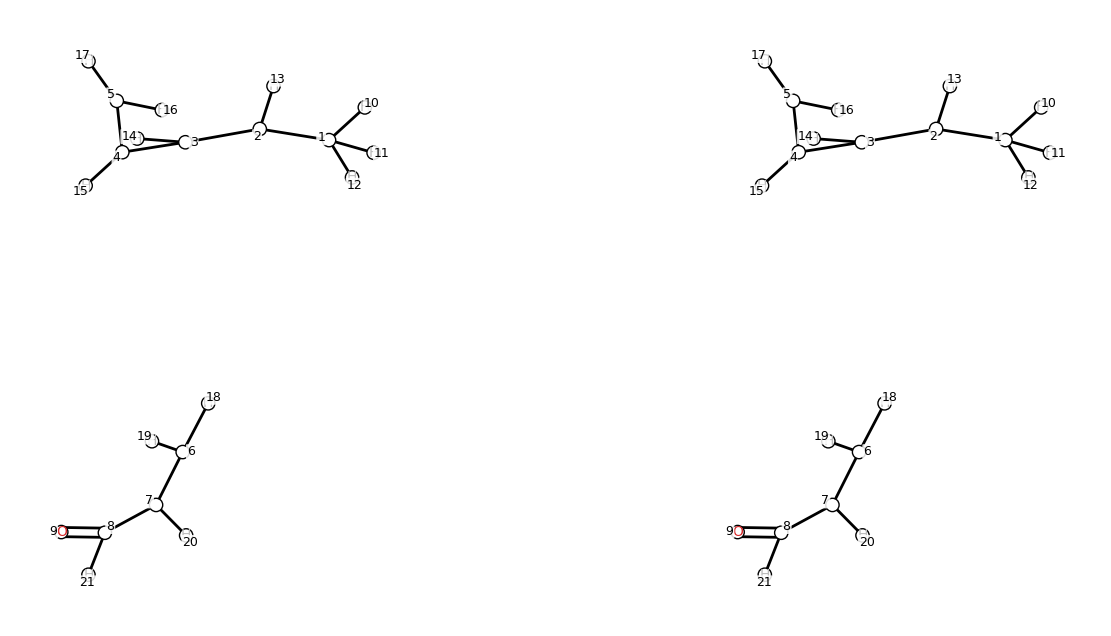

In [11]:
D1, mk1 = pushout_complement(L, K, G, matches[0])
D2, mk2 = pushout_complement(L, K, G, matches[1])

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

draw_molecular_graph(
    D1,
    show_indices=True,
    separate_components=False,
    ax=ax[0],
)

draw_molecular_graph(
    D2,
    show_indices=True,
    separate_components=False,
    ax=ax[1],
)

### 2.3 Pushout

Now we have $D$ and $m'$ (or $m_K$); with interface $K$ and right pattern $R$, we construct the pushout $H$


$$
  V(H)=V(D)\;\cup\;\bigl(V(R)\setminus V(K)\bigr)\ /\ \{\,x\sim m'(x)\ (x\in K)\,\},
  $$
  $$
  E(H)=E(D)\;\cup\;m''\bigl(E(R)\bigr),
$$
where $m'':V(R)\to V(H)$ maps $x\mapsto m_K(x)$ for $x\in K$ and sends $x\in V(R)\setminus V(K)$ to fresh copies in $H$.



In [12]:
def pushout(
    R: nx.Graph,
    K: nx.Graph,
    D: nx.Graph,
    m_K: Dict[Any, Any],
    *,
    order_key: str = "order",
    strict_id_freshness: bool = True,
) -> Tuple[nx.Graph, Dict[Any, Any]]:

    K_nodes = set(K.nodes())
    R_nodes = set(R.nodes())
    D_nodes = set(D.nodes())

    if not K_nodes.issubset(R_nodes):
        raise ValueError("K.nodes() must be subset of R.nodes()")
    if not set(m_K.keys()).issuperset(K_nodes):
        raise ValueError("m_K must be defined on all K nodes")
    if not set(m_K.values()).issubset(D_nodes):
        raise ValueError("m_K images must lie in D")

    # start with H = D
    H = D.copy()

    # build node map h: R -> H
    h: Dict[Any, Any] = {}

    # interface nodes: use m_K
    for k in K_nodes:
        h[k] = m_K[k]

    # nodes in R\K: create fresh nodes in H
    # (If IDs already exist in H and strict_id_freshness=False, reuse them.)
    for v in R_nodes - K_nodes:
        if v in H:
            if strict_id_freshness:
                raise ValueError(f"Node id collision outside K: {v}")
            # reuse existing id
            h[v] = v
        else:
            H.add_node(v, **dict(R.nodes[v]))
            h[v] = v

    # add edges from R (mapped into H) and relabel to R's order
    for u, v, edata in R.edges(data=True):
        hu, hv = h[u], h[v]

        if not H.has_node(hu) or not H.has_node(hv):
            raise ValueError(
                f"Internal error: mapped endpoints missing in H for R edge ({u},{v})"
            )

        if not H.has_edge(hu, hv):
            H.add_edge(hu, hv, **dict(edata))

        # relabel bond order to R's order (your semantics)
        if order_key not in edata:
            raise KeyError(f"R edge ({u},{v}) missing '{order_key}'")
        H.edges[hu, hv][order_key] = float(edata[order_key])

    return H, h

In [13]:
H1, h1 = pushout(R, K, D1, mk1)
H2, h2 = pushout(R, K, D2, mk2)

**Q3 — Implicit hydrogen**

Convert explicit hydrogen nodes into an integer `hcount` attribute on their bonded heavy atom.
Robust, configurable, and returns a new graph (or mutates in-place).

---

<details> <summary><b>Solution</b></summary>

```python
import networkx as nx
def h_to_implicit(G: nx.Graph) -> nx.Graph:
    """Convert explicit hydrogen atoms to implicit counts on heavy atoms.

    For each hydrogen atom ('element' == 'H'), its neighbor (assumed to be a heavy atom)
    will have its 'hcount' attribute incremented. The hydrogen nodes are then removed.

    Parameters
    ----------
    G : nx.Graph
        Input graph with explicit hydrogen atoms as nodes (element='H').
        Heavy atoms must have 'element' and optionally 'hcount' attributes.

    Returns
    -------
    nx.Graph
        A copy of the original graph with hydrogen atoms removed and their counts
        added to the corresponding heavy atoms' 'hcount' attribute.
    """
    H2 = G.copy()
    h_nodes = [n for n, d in H2.nodes(data=True) if d.get("element") == "H"]

    for h in h_nodes:
        neighbors = list(H2.neighbors(h))
        for heavy in neighbors:
            if H2.nodes[heavy].get("element") != "H":
                H2.nodes[heavy]["hcount"] = H2.nodes[heavy].get("hcount", 0) + 1
        H2.remove_node(h)

    return H2

```

</details>

Now we make it into 1 pipeline now

In [14]:
from synkit.IO import graph_to_smi, smiles_to_graph, rsmi_to_graph
from synkit.Graph.Hyrogen._misc import h_to_implicit  # assume we have now


def dpo_rule_apply(smiles, rule):
    G = smiles_to_graph(smiles)
    L, R = rsmi_to_graph(rule)

    # 1. find match
    matches = find_pattern_match_components(host=G, pattern=L)

    # 2. Build pushout complement
    Ds, mks = zip(*(pushout_complement(L, K, G, m) for m in matches))

    # 3. Pushout
    Hs, _ = zip(*(pushout(R, K, D, mk) for D, mk in zip(Ds, mks)))
    Hs = [h_to_implicit(i) for i in list(Hs)]

    # 4 sanity check
    out_smi = [smi for H in Hs if (smi := graph_to_smi(H)) is not None]
    out_rsmi = [f'{smiles}>>{i}' for i in out_smi]
    return out_rsmi

In [15]:
# Now we define left and right patterns with atom map
input = 'CC=CC=C.C=CC=O'
rule = '[C:5]=[C:6].[C:2]([C:3]=[C:4])=[C:1]>>[C:2]1=[C:3][C:4][C:5][C:6][C:1]1'
dpo_rule_apply(input, rule)

['CC=CC=C.C=CC=O>>CC1C=CCCC1C=O', 'CC=CC=C.C=CC=O>>CC1C=CCC(C=O)C1']

How do we obtain **atom maps** for the generated reactions?

In DPO rewriting we explicitly construct the transformation
$$
G \;\longrightarrow\; H,
$$
rather than inferring correspondence post hoc.

**Key observation**

- Nodes of the host graph \(G\) that are **preserved** through the
  pushout complement and pushout remain the *same graph nodes* in \(H\).
- Therefore, **node indices are preserved along the rewrite**.

**Consequence**

We can directly use the node index as the atom-map number:
$$
\texttt{atom\_map}(v) \;=\; \texttt{node\_id}(v),
\qquad v \in V(H).
$$

In [16]:
import networkx as nx
from typing import Hashable


def set_atom_map_from_node_index(
    G: nx.Graph,
    *,
    atom_map_attr: str = "atom_map",
    inplace: bool = False,
) -> nx.Graph:
    H = G if inplace else G.copy()

    for v in H.nodes:
        H.nodes[v][atom_map_attr] = v

    return H

In [17]:
def dpo_rule_apply(smiles, rule, use_aam=True):
    """
    Apply a DPO rewrite rule to an input SMILES.

    Pipeline:
      1) SMILES -> host graph G
      2) Rule -> L, R graphs
      3) Find injective matches m : L -> G
      4) Pushout complement: (D, m_K)
      5) Pushout: D + R -> H
      6) Convert explicit H to implicit hydrogens
      7) Graph -> product SMILES
    """
    # 0. Parse input
    G = smiles_to_graph(smiles)
    L, R = rsmi_to_graph(rule)

    # 1. Find matches m : L -> G
    matches = list(find_pattern_match_components(host=G, pattern=L))
    if not matches:
        return []

    # 2. Pushout complements
    Ds = []
    mks = []
    for m in matches:
        try:
            D, mk = pushout_complement(L, K, G, m)
        except ValueError:
            # dangling condition or invalid match
            continue
        Ds.append(D)
        mks.append(mk)

    if not Ds:
        return []

    # 3. Pushouts
    Hs = []
    for D, mk in zip(Ds, mks):
        try:
            H, _ = pushout(R, K, D, mk)
        except ValueError:
            continue
        Hs.append(h_to_implicit(H))

    if not Hs:
        return []

    if use_aam:
        G = set_atom_map_from_node_index(G)
        smiles = graph_to_smi(G)
        Hs = [set_atom_map_from_node_index(i) for i in Hs]
    # 4. Convert to SMILES (single evaluation, deduplicated)
    out_smi = {smi for H in Hs if (smi := graph_to_smi(H)) is not None}

    return [f"{smiles}>>{smi}" for smi in out_smi]

In [18]:
input = 'CC=CC=C.C=CC=O'
rule = '[C:5]=[C:6].[C:2]([C:3]=[C:4])=[C:1]>>[C:2]1=[C:3][C:4][C:5][C:6][C:1]1'
rsmi1, rsmi2 = dpo_rule_apply(input, rule, True)

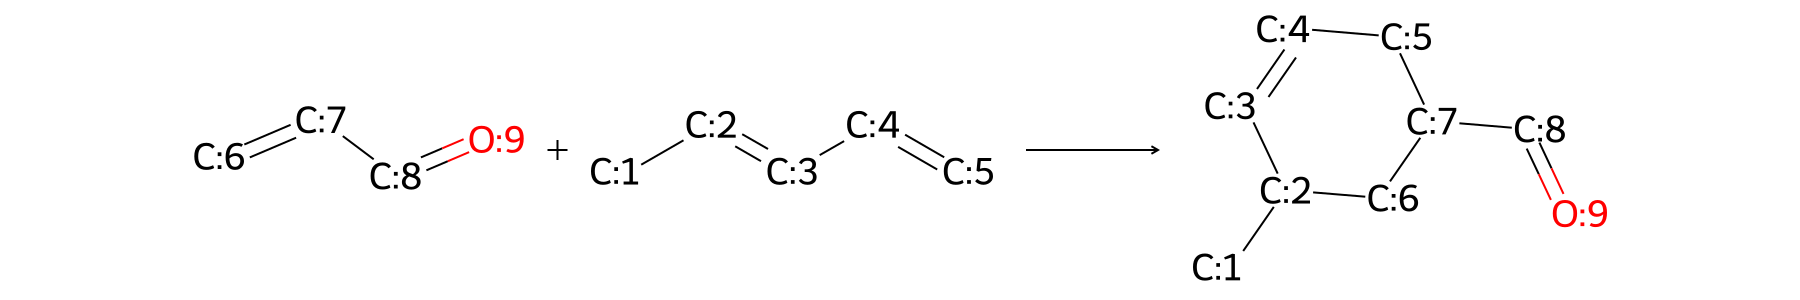

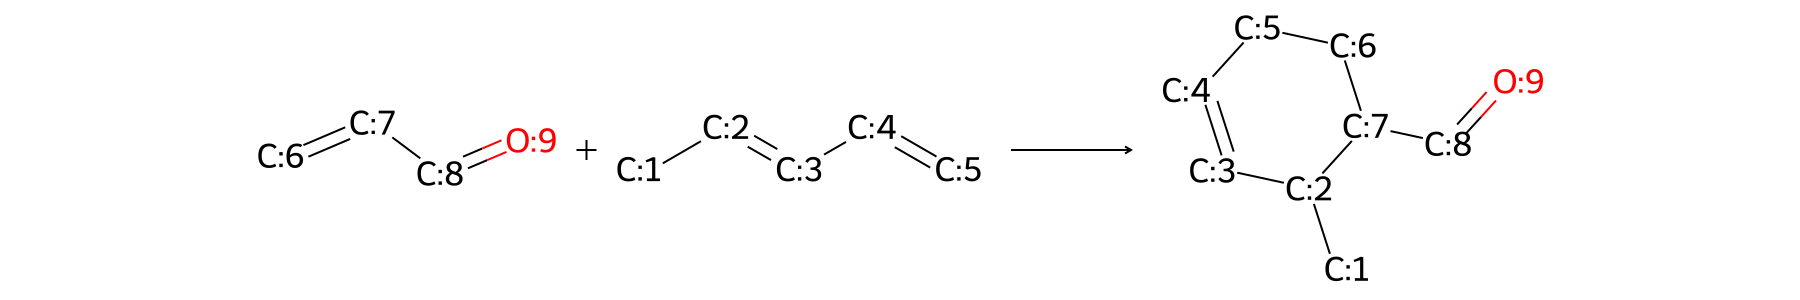

In [19]:
from synedu.Utils.rxn_vis import visualize_reaction
from IPython.display import SVG

svg1 = visualize_reaction(
    rsmi1,
    svg=True,
    highlight_changes=True,
    legend="solution 1",
)
svg2 = visualize_reaction(
    rsmi2,
    svg=True,
    highlight_changes=True,
    legend="solution 2",
)
display(SVG(svg1))
display(SVG(svg2))

**Q4 — Inverse rule application**

Given an input SMILES `CC1C=CCCC1C=O`, can we apply the **inverse** of the above rule?

---

<details> <summary><b>Solution</b></summary>

Yes.  
In DPO rewriting, a rule
$$
p:\quad L \xleftarrow{} K \xrightarrow{} R
$$
is inverted simply by **swapping $L$ and $R$**. The same categorical
construction (match → pushout complement → pushout) applies.


```python

def dpo_rule_apply(smiles, rule, use_aam=True, inverse = False):

    # 0. Parse input
    G = smiles_to_graph(smiles)
    
    if inverse:
        R, L = rsmi_to_graph(rule)
    else:
        L, R = rsmi_to_graph(rule)

    # 1. Find matches m : L -> G
    matches = list(find_pattern_match_components(host=G, pattern=L))
    if not matches:
        return []

    # 2. Pushout complements
    Ds = []
    mks = []
    for m in matches:
        try:
            D, mk = pushout_complement(L, K, G, m)
        except ValueError:
            # dangling condition or invalid match
            continue
        Ds.append(D)
        mks.append(mk)

    if not Ds:
        return []

    # 3. Pushouts
    Hs = []
    for D, mk in zip(Ds, mks):
        try:
            H, _ = pushout(R, K, D, mk)
        except ValueError:
            continue
        Hs.append(h_to_implicit(H))

    if not Hs:
        return []

    if use_aam:
        G = set_atom_map_from_node_index(G)
        smiles = graph_to_smi(G)
        Hs = [set_atom_map_from_node_index(i) for i in Hs]
    # 4. Convert to SMILES (single evaluation, deduplicated)
    out_smi = {
        smi
        for H in Hs
        if (smi := graph_to_smi(H)) is not None
    }

    return [f"{smiles}>>{smi}" for smi in out_smi]

```

</details>

## 3. SynKit

Instead of implementing the full DPO pipeline manually, we can directly use
`SynReactor` from **SynKit**, which natively supports DPO rewriting with
implicit hydrogens.

In [20]:
from synkit.Synthesis.Reactor.syn_reactor import SynReactor

input = 'CC1C=CCCC1C=O'
rule = '[C:5]=[C:6].[C:2]([C:3]=[C:4])=[C:1]>>[C:2]1=[C:3][C:4][C:5][C:6][C:1]1'

reactor = SynReactor(
    substrate=input,
    template=rule,
    invert=True,
    implicit_temp=True,
    explicit_h=False,
    automorphism=False,
)
reactor.smarts

2026-01-16 16:25:45,636 - INFO - 1 mapping(s) discovered


['[CH2:6]=[CH:7][CH:8]=[O:9].[CH3:1][CH:2]=[CH:3][CH:4]=[CH2:5]>>[CH3:1][CH:2]1[CH:3]=[CH:4][CH2:5][CH2:6][CH:7]1[CH:8]=[O:9]']

## 4. Quiz



## 5. Discussion


## 6. References

1. <a id="ref-1"></a> RDKit documentation: https://www.rdkit.org/docs/  
2. <a id="ref-2"></a> NetworkX documentation: https://networkx.org/documentation/stable/
3. <a id="ref-3"></a> **SynKit**: A graph-based framework for rule-based reaction modeling  
   Phan, T.-L. *et al.* *Journal of Chemical Information and Modeling* (2025).  
   https://doi.org/10.1021/acs.jcim.5c02123
4. <a id="ref-4"></a> Schwaller, P. *et al.*  
   *Molecular Transformer: A Model for Uncertainty-Calibrated Chemical Reaction Prediction.*  
   **ACS Central Science** (2019).  
   https://doi.org/10.1021/acscentsci.9b00576

5. <a id="ref-5"></a> Schwaller, P. *et al.*  
   *Extraction of organic chemistry grammar from unsupervised learning of chemical reactions (RXNMapper).*  
   **Science Advances** (2021).  
   https://doi.org/10.1126/sciadv.abe4166

6. <a id="ref-6"></a> Phan, T.-L.; Weinbauer, K.; González Laffitte, M. E.; Pan, Y.; Merkle, D.; Andersen, J. L.; Fagerberg, R.; Flamm, C.; Stadler, P. F.  
   *SynTemp: Efficient Extraction of Graph-Based Reaction Rules from Large-Scale Reaction Databases.*  
   **Journal of Chemical Information and Modeling** (2025).  
   https://doi.org/10.1021/acs.jcim.4c01795

7. <a id="ref-7"></a> Nugmanov, R. I.; Mukhametgaleev, R. N.; Akhmetshin, T.; Gimadiev, T. R.; Afonina, V. A.; Madzhidov, T. I.; Varnek, A.  
   *CGRtools: Python Library for Molecule, Reaction, and Condensed Graph of Reaction Processing.*  
   **Journal of Chemical Information and Modeling** (2019), **59**, 2516–2521.  
   https://doi.org/10.1021/acs.jcim.9b00102

